<a href="https://colab.research.google.com/github/SaidCondoriRomero/SiS420_Inteligencia_Artificial/blob/main/Laboratorios/Laboratorio_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Condori Romero Said — Ing. Sistemas
## Laboratorio 3

# Origen del Dataset

### Página de obtención
El dataset fue descargado desde el **Repositorio UCI de Machine Learning**:  
https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset

Cada fila corresponde a una **URL analizada** — ya sea legítima o de phishing. Se extrajeron 54 características técnicas del código fuente de la página web y de la estructura de la URL para determinar si es fraudulenta o no.

### Variables del dataset
| Grupo | Variables | Descripción |
|-------|-----------|-------------|
| URL | `URLLength`, `NoOfLettersInURL`, `NoOfDegitsInURL`... | Características de la dirección web |
| Dominio | `DomainLength`, `IsDomainIP`, `NoOfSubDomain`... | Características del dominio |
| Seguridad | `IsHTTPS`, `HasObfuscation`, `URLSimilarityIndex`... | Indicadores de seguridad |
| Contenido | `LineOfCode`, `HasTitle`, `HasFavicon`, `IsResponsive`... | Características del contenido |
| Formularios | `HasSubmitButton`, `HasPasswordField`, `HasExternalFormSubmit`... | Elementos de formulario |
| Social | `HasSocialNet`, `Bank`, `Pay`, `Crypto`... | Palabras clave sospechosas |
| **Objetivo** | `label` | 1 = URL legítima, 0 = URL de phishing |

# Objetivo

Predecir si una **URL es legítima o de phishing** a partir de 50 características técnicas, usando regresión logística con dos métodos de optimización:



In [32]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Manejo de datos tabulares
import pandas as pd

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [33]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## Carga de Datos y Exploración Inicial

### Preprocesamiento — Paso 1: Carga del dataset

El dataset contiene columnas de texto (`FILENAME`, `URL`, `Domain`, `TLD`, `Title`) que deben descartarse
porque no aportan información numérica para el modelo.
Se usa **pandas** para manejar estas columnas mixtas sin errores.


In [34]:
# ── Opción A: leer desde Google Drive ─────────────────────────────────────────
ruta = '/content/gdrive/MyDrive/SIS420 Condori Romero Said/datasets/PhiUSIIL_Phishing_URL_Dataset.csv'
df = pd.read_csv(ruta)


print('Dimensiones del dataset (original):', df.shape)
print('Valores nulos:', df.isnull().sum().sum())
print()
print(df.head(10))

Dimensiones del dataset (original): (235795, 56)
Valores nulos: 0

     FILENAME                                 URL  URLLength  \
0  521848.txt    https://www.southbankmosaics.com         31   
1   31372.txt            https://www.uni-mainz.de         23   
2  597387.txt      https://www.voicefmradio.co.uk         29   
3  554095.txt         https://www.sfnmjournal.com         26   
4  151578.txt  https://www.rewildingargentina.org         33   
5   23107.txt     https://www.globalreporting.org         30   
6   23034.txt          https://www.saffronart.com         25   
7  696732.txt          https://www.nerdscandy.com         25   
8  739255.txt      https://www.hyderabadonline.in         29   
9   14486.txt                 https://www.aap.org         18   

                       Domain  DomainLength  IsDomainIP  TLD  \
0    www.southbankmosaics.com            24           0  com   
1            www.uni-mainz.de            16           0   de   
2      www.voicefmradio.co.uk       

### Preprocesamiento — Paso 2: Limpieza de columnas de texto

Se descartan las columnas no predictivas o de texto:
- `FILENAME` → identificador del archivo, la documentación indica que puede ignorarse
- `URL` → la URL completa en texto, no aporta como valor numérico
- `Domain` → nombre del dominio en texto
- `TLD` → extensión del dominio (`.com`, `.org`, etc.) en texto
- `Title` → título de la página web en texto

Quedan **50 características numéricas** listas para el modelo.

In [35]:

df = df.drop(['FILENAME', 'URL', 'Domain', 'TLD', 'Title'], axis=1)

print('Dimensiones despues de limpieza:', df.shape)
print('Columnas:', list(df.columns))

Dimensiones despues de limpieza: (235795, 51)
Columnas: ['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


###  Separación X / y y División 80/20

Se separan las **50 características** de la variable objetivo `label`.
Luego se divide el dataset en:
- **80% entrenamiento** (188,636 URLs) → `X_train`, `y_train` — el modelo aprende con estos datos
- **20% prueba** (47,159 URLs) → `X_test`, `y_test` — el modelo **nunca los ve** durante el entrenamiento




In [36]:
# Cargar datos
# Reorganizar columnas: label al final
cols = [c for c in df.columns if c != 'label'] + ['label']
df = df[cols]

data = df.values.astype(float)

X = data[:, :50]    # las primeras 50 columnas son las caracteristicas
y = data[:, 50]     # la columna 50 es la etiqueta: label
m = y.size
print('Total de ejemplos (m):', m)

# ── División 80% entrenamiento / 20% prueba ──────────────────────────────────
# np.random.seed garantiza que la division sea siempre la misma
np.random.seed(42)
indices = np.random.permutation(m)

m_train = int(m * 0.8)   # 80% para entrenar
m_test  = m - m_train    # 20% para probar

train_idx = indices[:m_train]
test_idx  = indices[m_train:]

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print('Ejemplos de entrenamiento (80%): {:,}'.format(m_train))
print('Ejemplos de prueba       (20%): {:,}'.format(m_test))
print()

# imprimir algunos puntos de datos de entrenamiento
print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:,1]', 'label'))
print('-'*26)
for i in range(10):
    print('{:8.4f}{:8.4f}{:10.0f}'.format(X_train[i, 0], X_train[i, 1], y_train[i]))

Total de ejemplos (m): 235795
Ejemplos de entrenamiento (80%): 188,636
Ejemplos de prueba       (20%): 47,159

  X[:,0]  X[:,1]     label
--------------------------
 24.0000 17.0000         1
 59.0000 28.0000         0
385.0000 27.0000         0
 19.0000  6.0000         0
 35.0000 28.0000         1
 31.0000 24.0000         1
 44.0000 15.0000         0
 27.0000 21.0000         0
 40.0000 29.0000         0
 24.0000 18.0000         0


### Visualización de los datos

Antes de implementar el modelo se visualizan las distribuciones de las características
más relevantes separadas por clase (legítima vs phishing).
Esto ayuda a entender qué tan separables son las dos clases.

In [37]:
def plotData(X, y):
    # Grafica los puntos de datos X y y en una nueva figura.
    # Grafica los puntos con * para los positivos (legitimas) y o para los negativos (phishing).

    # Crea una nueva figura
    fig = pyplot.figure()

    # Indices de ejemplos positivos y negativos
    pos = y == 1
    neg = y == 0

    # Graficar ejemplos
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=5, alpha=0.3, label='Legitima')
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=4, mec='k', mew=1, alpha=0.3, label='Phishing')

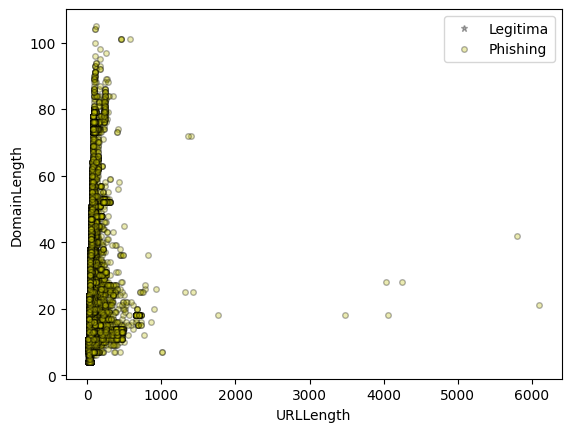

In [38]:
plotData(X_train[:, :2], y_train)
# adiciona etiquetas para los ejes
pyplot.xlabel('URLLength')
pyplot.ylabel('DomainLength')
pyplot.legend(['Legitima', 'Phishing'])
pass

## Regresión Logística

### Función Sigmoidea

La hipótesis para la regresión logística se define como:

$$h_\theta(x) = g(\theta^T x)$$

donde la función $g$ es la función sigmoidea:

$$g(z) = \frac{1}{1+e^{-z}}$$

Para valores positivos grandes de $z$, la sigmoide se acerca a 1 (legítima).
Para valores negativos grandes, se acerca a 0 (phishing).
En $z=0$ la función retorna exactamente 0.5 (límite de decisión).

In [39]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la entrada a un arreglo numpy
    z = np.array(z)

    z = np.clip(z, -250, 250)

    g = 1 / (1 + np.exp(-z))

    return g

In [40]:
# Prueba la implementacion de la funcion sigmoid
z = [-100, 0.5, 1000000]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [-100, 0.5, 1000000] ) =  [3.72007598e-44 6.22459331e-01 1.00000000e+00]


### Normalización y Término de Intersección

Se normaliza usando **solo los datos de entrenamiento** (`X_train`) para calcular `mu` y `sigma`.
Luego se aplica la misma normalización a `X_test` — esto es crítico para no contaminar la prueba.

Finalmente se añade la columna de unos a ambos conjuntos para el término de intercepción $\theta_0$.

In [41]:

# Normalizar SOLO con X_train — luego aplicar a X_test con los mismos mu y sigma
def featureNormalize(X):
    mu    = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1   # evitar division por cero en columnas constantes
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train_norm, mu, sigma = featureNormalize(X_train)


X_test_norm = (X_test - mu) / sigma

# Agrega el termino de intercepción a ambos conjuntos
m_train, n = X_train_norm.shape
X_train = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
X_test  = np.concatenate([np.ones((m_test,  1)), X_test_norm],  axis=1)

print('X_train shape:', X_train.shape)
print('X_test  shape:', X_test.shape)

X_train shape: (188636, 51)
X_test  shape: (47159, 51)


### Función de Costo

La función de costo en regresión logística es:

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log(h_\theta(x^{(i)})) - (1-y^{(i)}) \log(1-h_\theta(x^{(i)})) \right]$$

A diferencia de la regresión lineal, aquí se usa la **log-loss** porque la variable objetivo es binaria (0 o 1).

In [42]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))

    # Protege log(0) para evitar nan en J_history y gráfica en blanco
    h = np.clip(h, 1e-10, 1 - 1e-10)

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

### Descenso por el Gradiente

La regla de actualización de theta en cada iteración es:

$$\theta := \theta - \frac{\alpha}{m} X^T (h_\theta(X) - y)$$

La diferencia clave con la regresión lineal es que $h_\theta(x) = sigmoid(\theta^T x)$, no una función lineal.

In [43]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será actualizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

### Entrenamiento Descenso por el Gradiente

- `alpha = 0.001`: tasa de aprendizaje
- `num_iters = 6000`: iteraciones
- `theta = np.zeros(51)`: 51 parámetros (1 sesgo + 50 características)

theta calculado por el descenso por el gradiente: [ 5.32460736e-01 -1.71263185e-01 -8.58079897e-02 -3.74299967e-02
  1.30507030e+00  1.97662829e-01 -1.59222439e-01  4.18186797e-01
 -2.23389785e-01  5.04736067e-01 -4.21147459e-02 -9.94028070e-03
 -3.33694247e-02 -2.13739581e-01 -4.60175362e-01 -1.67530086e-01
 -4.72070272e-01 -5.69421516e-02 -1.35851990e-01 -2.27726842e-02
 -3.32338151e-01 -5.31178818e-01  1.17802392e+00  2.02953452e-01
 -1.01578046e-01  4.35259639e-01  3.21623905e-01  2.11414584e-01
  3.51171133e-01  2.13789064e-01  3.13668099e-01 -9.61843879e-02
 -9.80036532e-02  6.01209308e-01  5.03556107e-02  1.22289155e-01
  4.80078510e-02  7.64766061e-01  3.93186289e-01  2.83895905e-01
 -6.07703677e-02 -7.02700121e-04  1.89123932e-01 -2.87110797e-02
  7.19765724e-01  2.18904933e-01  6.33584542e-02  3.26373226e-01
  2.54871227e-01  6.80355504e-02  2.23053715e-01]

Probabilidad para URL de prueba 0 (usando el descenso por el gradiente): 0.0051
Clasificacion: PHISHING (label=0)
Etiqu

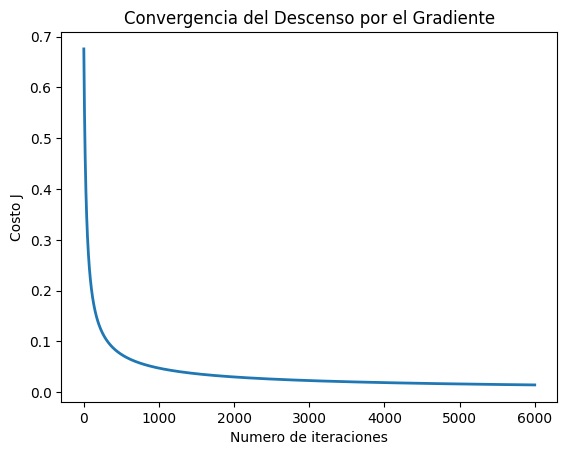

In [44]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01
num_iters = 6000

# inicializa theta y ejecuta el descenso por el gradiente
# ENTRENAMIENTO: solo se usan X_train e y_train
theta = np.zeros(X_train.shape[1])
theta, J_history = descensoGradiente(theta, X_train, y_train, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Descenso por el Gradiente')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# Guardar theta del descenso por el gradiente para comparar al final
theta_gd = theta.copy()

# Verificar con la primera URL del conjunto de PRUEBA
X_array = X_test[0, :]
prob = sigmoid(np.dot(X_array, theta_gd))

print('\nProbabilidad para URL de prueba 0 (usando el descenso por el gradiente): {:.4f}'.format(prob))
print('Clasificacion: {}'.format('LEGITIMA (label=1)' if prob >= 0.5 else 'PHISHING (label=0)'))
print('Etiqueta real: {:.0f}'.format(y_test[0]))

### Función de Costo con Gradiente

Para usar `scipy.optimize.minimize` se necesita una función que retorne
tanto el costo $J(\theta)$ como el gradiente $\nabla J(\theta)$ en un solo paso:

$$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$$

In [45]:
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X.dot(theta.T))

    # Protege log(0) para evitar nan
    h = np.clip(h, 1e-10, 1 - 1e-10)

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)

    return J, grad

In [46]:
# Inicializacion de parametros de ajuste
initial_theta = np.zeros(n + 1)
print(initial_theta)
cost, grad = costFunction(initial_theta, X_train, y_train)

print('Costo en theta inicial (zeros): {:.3f}'.format(cost))
print('Gradiente en theta inicial (primeros 5 valores):')
print('\t{}'.format(grad[:5]))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0.]
Costo en theta inicial (zeros): 0.693
Gradiente en theta inicial (primeros 5 valores):
	[-0.07209122  0.11599162  0.14014153  0.030367   -0.42571919]


### Optimización con `scipy.optimize.minimize`

En lugar de ejecutar el descenso por el gradiente manualmente,
`scipy.optimize.minimize` con el método **TNC** encuentra los parámetros óptimos
de forma automática y más eficiente, especialmente con 50 características.


In [47]:
# Establecer las opciones para optimize.minimize
options = {'maxfun': 1000}

res = optimize.minimize(costFunction,
                        initial_theta,
                        (X_train, y_train),
                        jac=True,
                        method='TNC',
                        options=options)

cost = res.fun
theta = res.x

print('Costo con un valor de theta encontrado por optimize.minimize: {:.6f}'.format(cost))
print('theta (primeros 5 valores):')
print('\t{}'.format(theta[:5]))

Costo con un valor de theta encontrado por optimize.minimize: 0.000002
theta (primeros 5 valores):
	[-36.85454971   4.78107888  25.73729119   1.86511076 128.71331531]


### Función de Predicción

Una vez entrenado el modelo se predice si una URL es legítima (1) o phishing (0).
Se aplica un **umbral de 0.5**: si $sigmoid(\theta^T x) \geq 0.5$ → legítima, si no → phishing.

In [48]:
def predict(theta, X):
    """
    Predecir si la etiqueta es 0 o 1 mediante regresión logística aprendida.
    Calcula las predicciones para X usando un umbral en 0.5
    (es decir, si sigmoid(theta.T * x) >= 0.5, predice 1 = LEGITIMA)
    """
    m = X.shape[0]  # Numero de ejemplos de entrenamiento

    p = np.zeros(m)

    p = np.round(sigmoid(X.dot(theta.T)))
    return p

### Evaluación del Modelo

Se evalúa la precisión del modelo sobre el conjunto de entrenamiento y
se realizan predicciones individuales para URLs específicas.

In [49]:
# Predice la probabilidad para la primera URL del conjunto de PRUEBA
prob = sigmoid(np.dot(X_test[0, :], theta))
print('Para la URL de prueba 0, se predice una probabilidad de: {:.3f}'.format(prob))
print('Clasificacion: {}'.format('LEGITIMA' if prob >= 0.5 else 'PHISHING'))
print('Etiqueta real: {:.0f}'.format(y_test[0]))
print()

# Precision sobre el conjunto de PRUEBA (20% - datos no vistos durante entrenamiento)
p = predict(theta, X_test)
print('Precision de PRUEBA (20% datos no vistos): {:.2f} %'.format(np.mean(p == y_test) * 100))

Para la URL de prueba 0, se predice una probabilidad de: 0.000
Clasificacion: PHISHING
Etiqueta real: 0

Precision de PRUEBA (20% datos no vistos): 99.99 %


## 100 Predicciones sobre el Conjunto de Prueba

Se toman 100 URLs del **conjunto de prueba** (20% del dataset que el modelo **nunca vio** durante el entrenamiento)
y se compara la predicción contra la etiqueta real.

In [50]:

X_pred = X_test[:100, :]
y_pred = y_test[:100]

# Predicciones con theta de optimize.minimize
predicciones = predict(theta, X_pred)
probabilidades = sigmoid(X_pred.dot(theta.T))

# Mostrar comparacion real vs predicho
print('{:>5s}{:>10s}{:>12s}{:>12s}{:>10s}'.format(
    'Ej', 'Real', 'Predicho', 'Probabilidad', 'Correcto'))
print('-' * 52)
for i in range(20):
    correcto = '✓' if predicciones[i] == y_pred[i] else '✗'
    label_real = 'LEGITIMA' if y_pred[i] == 1 else 'PHISHING'
    label_pred = 'LEGITIMA' if predicciones[i] == 1 else 'PHISHING'
    print('{:>5d}{:>10s}{:>12s}{:>12.4f}{:>10s}'.format(
        i+1, label_real, label_pred, probabilidades[i], correcto))

precision_100 = np.mean(predicciones == y_pred) * 100
print()
print('Precision sobre 100 predicciones (conjunto prueba): {:.2f} %'.format(precision_100))

   Ej      Real    PredichoProbabilidad  Correcto
----------------------------------------------------
    1  PHISHING    PHISHING      0.0000         ✓
    2  PHISHING    PHISHING      0.0000         ✓
    3  PHISHING    PHISHING      0.0000         ✓
    4  LEGITIMA    LEGITIMA      1.0000         ✓
    5  LEGITIMA    LEGITIMA      1.0000         ✓
    6  PHISHING    PHISHING      0.0000         ✓
    7  PHISHING    PHISHING      0.0000         ✓
    8  PHISHING    PHISHING      0.0000         ✓
    9  PHISHING    PHISHING      0.0000         ✓
   10  PHISHING    PHISHING      0.0000         ✓
   11  LEGITIMA    LEGITIMA      1.0000         ✓
   12  LEGITIMA    LEGITIMA      1.0000         ✓
   13  LEGITIMA    LEGITIMA      1.0000         ✓
   14  LEGITIMA    LEGITIMA      1.0000         ✓
   15  LEGITIMA    LEGITIMA      1.0000         ✓
   16  LEGITIMA    LEGITIMA      1.0000         ✓
   17  PHISHING    PHISHING      0.0000         ✓
   18  LEGITIMA    LEGITIMA      1.0000        

## Comparativa: Descenso por el Gradiente vs scipy.optimize

Se comparan ambos métodos sobre las mismas 100 URLs.

=== Comparativa de los 2 métodos (100 predicciones — conjunto de prueba) ===
  Descenso por el Gradiente:     100.00 %
  scipy.optimize (TNC):          100.00 %


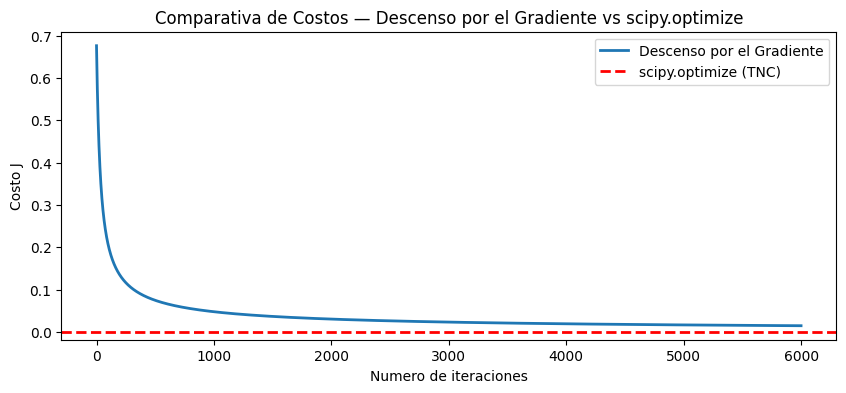

In [51]:
# Predicciones con theta del descenso por el gradiente (conjunto de PRUEBA)
predicciones_gd = predict(theta_gd, X_pred)
precision_gd = np.mean(predicciones_gd == y_pred) * 100

# Predicciones con theta de optimize.minimize (conjunto de PRUEBA)
predicciones_opt = predict(theta, X_pred)
precision_opt = np.mean(predicciones_opt == y_pred) * 100

print('=== Comparativa de los 2 métodos (100 predicciones — conjunto de prueba) ===')
print('  Descenso por el Gradiente:     {:.2f} %'.format(precision_gd))
print('  scipy.optimize (TNC):          {:.2f} %'.format(precision_opt))

# Grafica comparativa de costos
pyplot.figure(figsize=(10, 4))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, label='Descenso por el Gradiente')
pyplot.axhline(y=cost, color='red', linestyle='--', lw=2, label='scipy.optimize (TNC)')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Comparativa de Costos — Descenso por el Gradiente vs scipy.optimize')
pyplot.legend()

## Costo y Precisión:

In [52]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0]  # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []
    p_history = []   # historial de precision

    for i in range(num_iters):
        h     = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))

        # Precision en cada iteracion sobre X_train
        p_iter = np.mean(np.round(sigmoid(X.dot(theta.T))) == y)
        p_history.append(p_iter)

    return theta, J_history, p_history

entrenamiento con gráficas de costo y precisión

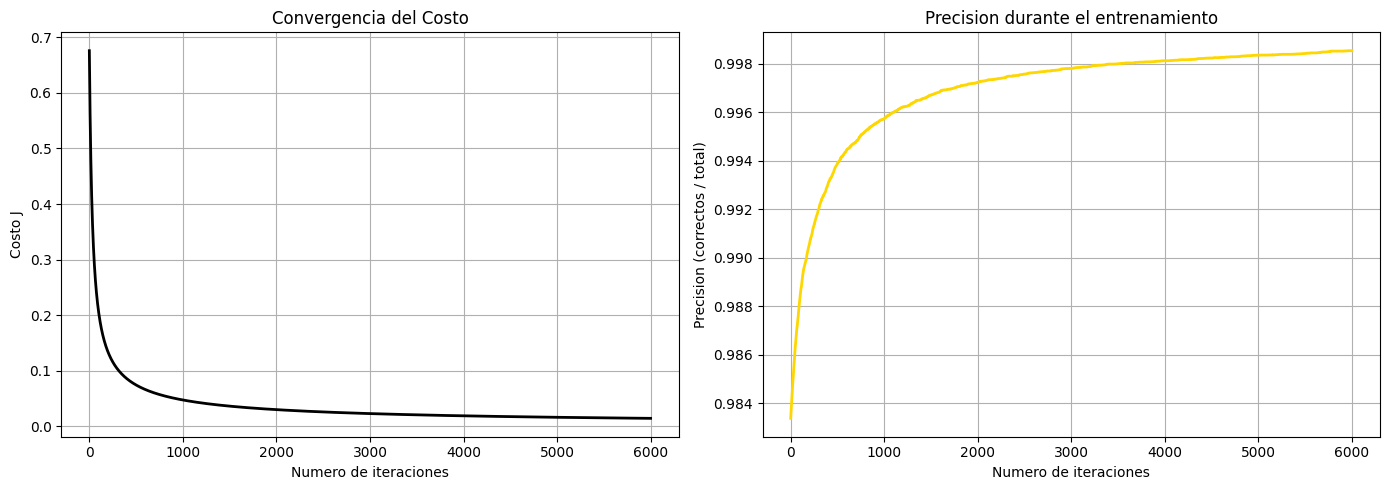

theta calculado por el descenso por el gradiente: [ 0.53246074 -0.17126318 -0.08580799 -0.03743     1.3050703 ] ...
Costo final tras 6000 iteraciones:        0.0145
Precision final en entrenamiento:  99.85 %

Probabilidad para URL de prueba 0 (usando el descenso por el gradiente): 0.0051
Clasificacion: PHISHING (label=0)
Etiqueta real: 0


In [53]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha     = 0.01
num_iters = 6000

# inicializa theta y ejecuta el descenso por el gradiente
# ENTRENAMIENTO: solo se usan X_train e y_train
theta = np.zeros(X_train.shape[1])
theta, J_history, p_history = descensoGradiente(theta, X_train, y_train, alpha, num_iters)

# Grafica costo y precision lado a lado
fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(14, 5))

# Costo
ax1.plot(np.arange(len(J_history)), J_history, color='black', lw=2)
ax1.set_xlabel('Numero de iteraciones')
ax1.set_ylabel('Costo J')
ax1.set_title('Convergencia del Costo')
ax1.grid(True)

# Precision
ax2.plot(np.arange(len(p_history)), p_history, color='gold', lw=2)
ax2.set_xlabel('Numero de iteraciones')
ax2.set_ylabel('Precision (correctos / total)')
ax2.set_title('Precision durante el entrenamiento')
ax2.grid(True)

pyplot.tight_layout()
pyplot.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s} ...'.format(str(theta[:5])))
print('Costo final tras {:d} iteraciones:        {:.4f}'.format(num_iters, J_history[-1]))
print('Precision final en entrenamiento:  {:.2f} %'.format(p_history[-1] * 100))

# Guardar theta del descenso por el gradiente para comparar al final
theta_gd = theta.copy()

# Verificar con la primera URL del conjunto de PRUEBA
X_array = X_test[0, :]
prob    = sigmoid(np.dot(X_array, theta_gd))

print('\nProbabilidad para URL de prueba 0 (usando el descenso por el gradiente): {:.4f}'.format(prob))
print('Clasificacion: {}'.format('PHISHING (label=0)' if prob < 0.5 else 'LEGITIMA (label=1)'))
print('Etiqueta real: {:.0f}'.format(y_test[0]))

## Interfaz Gráfica Interactiva de Predicción


In [54]:
import ipywidgets as widgets
from IPython.display import display, clear_output

style  = {'description_width': 'initial'}
layout = widgets.Layout(width='450px')

# Columnas reales del dataset cargado
cols        = df.drop('label', axis=1).columns.tolist()
total_filas = len(df)

# Detectar automaticamente cual valor es phishing en el dataset
VALOR_PHISHING = int(df['label'].value_counts().idxmin())
print('Valor que representa PHISHING en el dataset:', VALOR_PHISHING)

titulo = widgets.HTML(
    "<h2 style='color:#00ff88; font-family:monospace;'>"
    "Detector de Phishing - SIS420</h2>"
    "<p style='color:#aaa; font-family:monospace;'>"
    "Dataset: <b style='color:#fff'>PhiUSIIL Phishing URL</b> - "
    + str(total_filas) + " filas cargadas</p>"
)

# Selector de fila real del dataset
selector_fila = widgets.BoundedIntText(
    value=0, min=0, max=total_filas - 1,
    description='Fila del dataset:',
    style=style, layout=layout
)
btn_cargar_fila     = widgets.Button(description='Cargar fila', button_style='info',
                                     layout=widgets.Layout(width='140px'))
label_etiqueta_real = widgets.HTML('')

# Features de la URL
feat_URLLength          = widgets.FloatText(value=30,  description='URLLength:',          style=style, layout=layout)
feat_URLSimilarityIndex = widgets.FloatText(value=100, description='URLSimilarityIndex:', style=style, layout=layout)
feat_IsHTTPS            = widgets.Dropdown(options=[('Si (1)', 1), ('No (0)', 0)], value=1,
                                            description='IsHTTPS:', style=style, layout=layout)
feat_NoOfSubDomain      = widgets.FloatText(value=1,   description='NoOfSubDomain:',      style=style, layout=layout)
feat_HasTitle           = widgets.Dropdown(options=[('Si (1)', 1), ('No (0)', 0)], value=1,
                                            description='HasTitle:', style=style, layout=layout)
feat_NoOfExternalRef    = widgets.FloatText(value=10,  description='NoOfExternalRef:',    style=style, layout=layout)
feat_LineOfCode         = widgets.FloatText(value=500, description='LineOfCode:',         style=style, layout=layout)
feat_HasObfuscation     = widgets.Dropdown(options=[('Si (1)', 1), ('No (0)', 0)], value=0,
                                            description='HasObfuscation:', style=style, layout=layout)

btn_phishing = widgets.Button(description='Ejemplo Phishing', button_style='danger',
                               layout=widgets.Layout(width='220px'))
btn_legitima = widgets.Button(description='Ejemplo Legitima',  button_style='success',
                               layout=widgets.Layout(width='220px'))
btn_predecir = widgets.Button(description='ANALIZAR URL', button_style='warning',
                               layout=widgets.Layout(width='450px', height='42px'))
salida = widgets.Output()

# Cargar fila del dataset en los campos
def cargar_fila(row, etiqueta_real=None):
    def get(col, default):
        return float(row[col]) if col in cols else default

    feat_URLLength.value          = get('URLLength', 30)
    feat_URLSimilarityIndex.value = get('URLSimilarityIndex', 100)
    feat_IsHTTPS.value            = int(get('IsHTTPS', 1))
    feat_NoOfSubDomain.value      = get('NoOfSubDomain', 1)
    feat_HasTitle.value           = int(get('HasTitle', 1))
    feat_NoOfExternalRef.value    = get('NoOfExternalRef', 10)
    feat_LineOfCode.value         = get('LineOfCode', 500)
    feat_HasObfuscation.value     = int(get('HasObfuscation', 0))

    if etiqueta_real is not None:
        es_phishing = (etiqueta_real == VALOR_PHISHING)
        color = '#ff003c' if es_phishing else '#00ff88'
        texto = 'PHISHING' if es_phishing else 'Legitima'
        label_etiqueta_real.value = (
            "<span style='color:" + color + "; font-family:monospace; font-weight:bold;'>"
            "Etiqueta real del dataset: " + texto + " (label=" + str(etiqueta_real) + ")</span>"
        )

def on_cargar_fila(b):
    idx = selector_fila.value
    row = df.drop('label', axis=1).iloc[idx]
    cargar_fila(row, etiqueta_real=int(df['label'].iloc[idx]))

def cargar_phishing(b):
    idx = np.where(y == VALOR_PHISHING)[0][0]
    row = df.drop('label', axis=1).iloc[idx]
    selector_fila.value = idx
    cargar_fila(row, etiqueta_real=VALOR_PHISHING)

def cargar_legitima(b):
    valor_legitima = 1 - VALOR_PHISHING
    idx = np.where(y == valor_legitima)[0][0]
    row = df.drop('label', axis=1).iloc[idx]
    selector_fila.value = idx
    cargar_fila(row, etiqueta_real=valor_legitima)

# Prediccion
def predecir(b):
    with salida:
        clear_output()

        x_final    = np.zeros(theta.shape)
        x_final[0] = 1.0  # intercepcion

        valores = {
            'URLLength':          feat_URLLength.value,
            'URLSimilarityIndex': feat_URLSimilarityIndex.value,
            'IsHTTPS':            feat_IsHTTPS.value,
            'NoOfSubDomain':      feat_NoOfSubDomain.value,
            'HasTitle':           feat_HasTitle.value,
            'NoOfExternalRef':    feat_NoOfExternalRef.value,
            'LineOfCode':         feat_LineOfCode.value,
            'HasObfuscation':     feat_HasObfuscation.value,
        }

        for nombre, valor in valores.items():
            if nombre in cols:
                i            = cols.index(nombre)
                x_final[i+1] = (valor - mu[i]) / sigma[i]

        prob = sigmoid(np.dot(x_final, theta))

        # Ajuste segun cual valor es phishing en el dataset
        if VALOR_PHISHING == 0:
            es_phishing = prob < 0.5
        else:
            es_phishing = prob >= 0.5

        clase = 'PHISHING' if es_phishing else 'LEGITIMA'

        etiqueta_real    = int(df['label'].iloc[selector_fila.value])
        real_es_phishing = (etiqueta_real == VALOR_PHISHING)
        acierto          = 'CORRECTO' if es_phishing == real_es_phishing else 'INCORRECTO'

        print('=' * 50)
        print('PREDICCION: ' + clase)
        print('   Probabilidad (sigmoide)  : {:.2f}%'.format(prob * 100))
        print('   Etiqueta real (dataset)  : {} (label={})'.format(
              'Phishing' if real_es_phishing else 'Legitima', etiqueta_real))
        print('   Resultado                : ' + acierto)
        print('   Precision global modelo  : {:.2f}%'.format(
              np.mean(predict(theta, X_test) == y_test) * 100))
        print('=' * 50)

btn_cargar_fila.on_click(on_cargar_fila)
btn_phishing.on_click(cargar_phishing)
btn_legitima.on_click(cargar_legitima)
btn_predecir.on_click(predecir)

# Layout final
display(widgets.VBox([
    titulo,
    widgets.HBox([btn_phishing, btn_legitima]),
    widgets.HBox([selector_fila, btn_cargar_fila]),
    label_etiqueta_real,
    widgets.HTML("<hr style='border-color:#333'>"),
    feat_URLLength, feat_URLSimilarityIndex, feat_IsHTTPS,
    feat_NoOfSubDomain, feat_HasTitle, feat_NoOfExternalRef,
    feat_LineOfCode, feat_HasObfuscation,
    widgets.HTML("<hr style='border-color:#333'>"),
    btn_predecir,
    salida
]))

Valor que representa PHISHING en el dataset: 0
